In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

import sys; sys.path.append("..") #to direct program to the root files
from utils.get_data import get_processed_files

from datetime import datetime

In [2]:
"""
Only run if there changes to ../utils/get_data folder
import importlib
import utils.get_data
importlib.reload(utils.get_data) #update with any changes made
"""

'\nOnly run if there changes to ../utils/get_data folder\nimport importlib\nimport utils.get_data\nimportlib.reload(utils.get_data) #update with any changes made\n'

In [3]:
# below are estimated date
TERRA_LUNA_CRASH_START_DATE = datetime.strptime("7 May 2022", "%d %B %Y")
GFC_CRASH_START_DATE = datetime.strptime("15 September 2008", "%d %B %Y")
PEG = 1 #For Terra Luna

In [4]:
erc_20_dfs = get_processed_files("..\\datasets\\processed\\erc_20")
erc_20_dfs

{'dai_price_data':      Unnamed: 0   timestamp    open  high     low   close        date
 0             0  1648857600  0.9999   1.0  0.9989  1.0000  2022-04-02
 1             1  1648944000  1.0000   1.0  0.9989  0.9990  2022-04-03
 2             2  1649030400  0.9990   1.0  0.9989  0.9995  2022-04-04
 3             3  1649116800  0.9994   1.0  0.9987  0.9999  2022-04-05
 4             4  1649203200  0.9999   1.0  0.9988  0.9991  2022-04-06
 ..          ...         ...     ...   ...     ...     ...         ...
 210         210  1667001600  0.9997   1.0  0.9987  1.0000  2022-10-29
 211         211  1667088000  1.0000   1.0  0.9991  1.0000  2022-10-30
 212         212  1667174400  1.0000   1.0  0.9989  1.0000  2022-10-31
 213         213  1667260800  1.0000   1.0  0.9983  0.9999  2022-11-01
 214         214  1667347200  0.9999   1.0  0.9990  0.9999  2022-11-02
 
 [215 rows x 7 columns],
 'event_data':     Unnamed: 0                                              event   timestamp  \
 0     

In [5]:
gfc_dfs = get_processed_files("..\\datasets\\processed\\gfc_data")
gfc_dfs

{'AIG':            Price       Close        High         Low        Open    Volume  \
 0     2005-01-04  792.226868  799.999660  790.552699  793.422682    379110   
 1     2005-01-05  805.380432  812.674866  796.651008  797.607644    558800   
 2     2005-01-06  806.695984  812.435949  799.999456  801.195269    408765   
 3     2005-01-07  808.130920  811.718362  804.304302  807.772191    311070   
 4     2005-01-10  809.565979  811.838055  804.782724  807.413529    253345   
 ...          ...         ...         ...         ...         ...       ...   
 2006  2012-12-21   26.324486   26.665474   26.021382   26.460879  31856600   
 2007  2012-12-24   26.673058   26.673058   26.172938   26.241136   6816400   
 2008  2012-12-26   26.786713   26.847335   26.491188   26.756405  11728100   
 2009  2012-12-27   26.498762   26.900372   26.066841   26.900372  16674800   
 2010  2012-12-28   26.203245   26.513925   26.142623   26.218398  11919300   
 
      ticker        date  
 0       AIG  20

# Statistical Functions

In [73]:
def calc_moving_avg(df, cols, date_col="date"):
    """
    Calculate moving averages of specified cols

    Args:
        df -> pd.DataFrame
        cols -> List<Str> : columns to calculate moving averages for
        date_col -> Str : represent the column name that represent the date
    Output:
        df -> pd.DataFrame
        - original dataframe with Moving averages columns
    """

    #sort dates
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).set_index(date_col)

    for col in cols:
        df[f'moving_avg_{col}'] = (
            df[col].rolling(window=3, min_periods=1).mean()
        )

        df[f'{col}_deviation_from_peg'] = df[col] - PEG
        df[f'{col}_abs_deviation'] = df[f'{col}_deviation_from_peg'].abs()

        df[f'moving_avg_{col}_slope'] = df[f'moving_avg_{col}'].diff()

        create_line_graph(
            df.reset_index(),
            x=date_col,
            y=f'moving_avg_{col}_slope'
        )

        create_line_graph(
            df.reset_index(),
            x=date_col,
            y=f'moving_avg_{col}'
        )

    return df


def calc_perc_changes(df, columns, date_col, is_gfc):
    """
    Calculate percentage changes of specified cols

    Args:
        df -> pd.DataFrame
        cols -> List<Str> : columns to calculate moving averages for
        date_col -> Str : represent the column name that represent the date
    Output:
        df -> pd.DataFrame
        - original dataframe with Moving averages columns
    """
    df[date_col] = pd.to_datetime(df[date_col], format="%Y-%m-%d")

    df = df.sort_values(date_col)
    print(df)
    for col in columns:
        # Calculate daily returns
        df[f'{col}_daily_return'] = df[col].pct_change()

        # Define a threshold for "stress" (e.g., >20% drop in one day)
        threshold = -0.2  # -20%
        df[f'{col}_stress_flag'] = df[f'{col}_daily_return'] < threshold

        # Print all stress events
        stress_events = df[df[f'{col}_stress_flag']]
        print("Stress events (sudden drops >20%):")
        print(stress_events[[col, f'{col}_daily_return']])
        print(stress_events)
        # Plot closing price and highlight stress events
        plt.figure(figsize=(12,6))
        plt.plot(df[date_col], df[col], label=f'{col} Price')
        plt.scatter(stress_events[date_col], stress_events[col], color='red', label='Stress Event', s=50)
        plt.title(f'{col} Price with Stress Events Highlighted')

        plt.axvline(
            x=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE,
            color='red',
            linestyle='--',
            linewidth=1,
            label='Crash Start'
        )


        plt.xlabel('Date')
        plt.ylabel(f'{col} Price')
        plt.legend()
        plt.grid(True)
        plt.show()

    return df


# Visualisation functions 

In [67]:
def create_candleLit_graph(df, name, is_gfc):
    """
    Show the trend of high, open, low, close prices

    Args:
        df -> pd.DataFrame
            should consist of the following columns ("open", "high", "low", "close", "date")
        name -> String, Name of the coin , or stocks , etc
    Output:
        candlestick chart
    """
    try :
        fig = go.Figure(data=[go.Candlestick(
            x=df.date,
            open=df['Open'],
            high=df['High'],
            low=df['Low'],
            close=df['Close'],
            increasing_line_color='green',
            decreasing_line_color='red'
        )])

        fig.add_shape(
            type="line", x0=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE, x1=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE, y0=df.Low.min(), y1=df.High.max() + 0.2,
            line=dict(color="red", width=1, dash="dash")
        )

        fig.update_layout(title=f'Price changes for {name}', xaxis_title='Date', yaxis_title="Prices")
        fig.show()
    except :
        print("unable to create candlestick chart")
        print("columns in df", df.columns.tolist())
        return

def create_line_graph(df, x, y, hue=None, title=None, is_gfc=False):
    """
    Analysing how input x column differ across y and for each hue
    using Line graph

    Args:
        df:
            pd.DataFrame (consisting of x,y,hue columns)
        x:
            string (name of column to be displayed as x-axis on line graph)
        y:
            string (name of column to be displayed as y-axis on line graph)
        hue:
            string (name of column to be displayed as hue on line graph)

    Output:
        Line graph figure
    """
    if hue:
        fig = px.line(df, x=x, y=y, color=hue)
    else:
        fig = px.line(df, x=x, y=y)

    fig.add_shape(
        type="line", x0=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE, x1=GFC_CRASH_START_DATE if is_gfc else TERRA_LUNA_CRASH_START_DATE, y0=df[y].min(), y1=df[y].max(),
        line=dict(color="red", width=1, dash="dash")
    )
    fig.update_layout(title=f'{y} Price changes across time' if title is None else title, xaxis_title=x, yaxis_title=f"{y} prices")
    fig.show()



### Concat related files
- concat all price_data
- concat all gfc data

merging  dai_price_data
     Unnamed: 0   timestamp    Open  High     Low   Close       date coins
0             0  1648857600  0.9999   1.0  0.9989  1.0000 2022-04-02   dai
1             1  1648944000  1.0000   1.0  0.9989  0.9990 2022-04-03   dai
2             2  1649030400  0.9990   1.0  0.9989  0.9995 2022-04-04   dai
3             3  1649116800  0.9994   1.0  0.9987  0.9999 2022-04-05   dai
4             4  1649203200  0.9999   1.0  0.9988  0.9991 2022-04-06   dai
..          ...         ...     ...   ...     ...     ...        ...   ...
210         210  1667001600  0.9997   1.0  0.9987  1.0000 2022-10-29   dai
211         211  1667088000  1.0000   1.0  0.9991  1.0000 2022-10-30   dai
212         212  1667174400  1.0000   1.0  0.9989  1.0000 2022-10-31   dai
213         213  1667260800  1.0000   1.0  0.9983  0.9999 2022-11-01   dai
214         214  1667347200  0.9999   1.0  0.9990  0.9999 2022-11-02   dai

[215 rows x 8 columns]
Stress events (sudden drops >20%):
Empty DataFrame
C

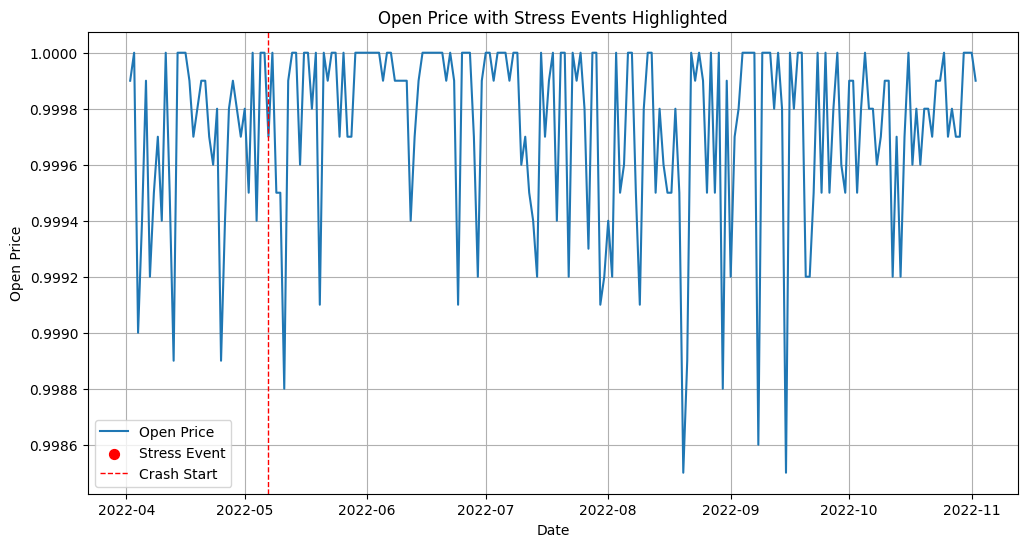

Stress events (sudden drops >20%):
Empty DataFrame
Columns: [High, High_daily_return]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, timestamp, Open, High, Low, Close, date, coins, Open_daily_return, Open_stress_flag, High_daily_return, High_stress_flag]
Index: []


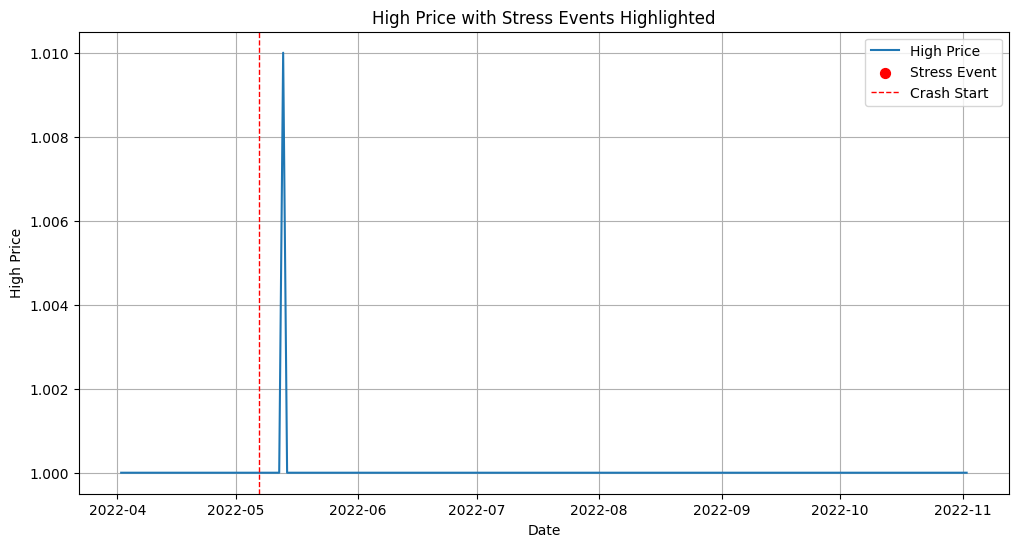

Stress events (sudden drops >20%):
Empty DataFrame
Columns: [Low, Low_daily_return]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, timestamp, Open, High, Low, Close, date, coins, Open_daily_return, Open_stress_flag, High_daily_return, High_stress_flag, Low_daily_return, Low_stress_flag]
Index: []


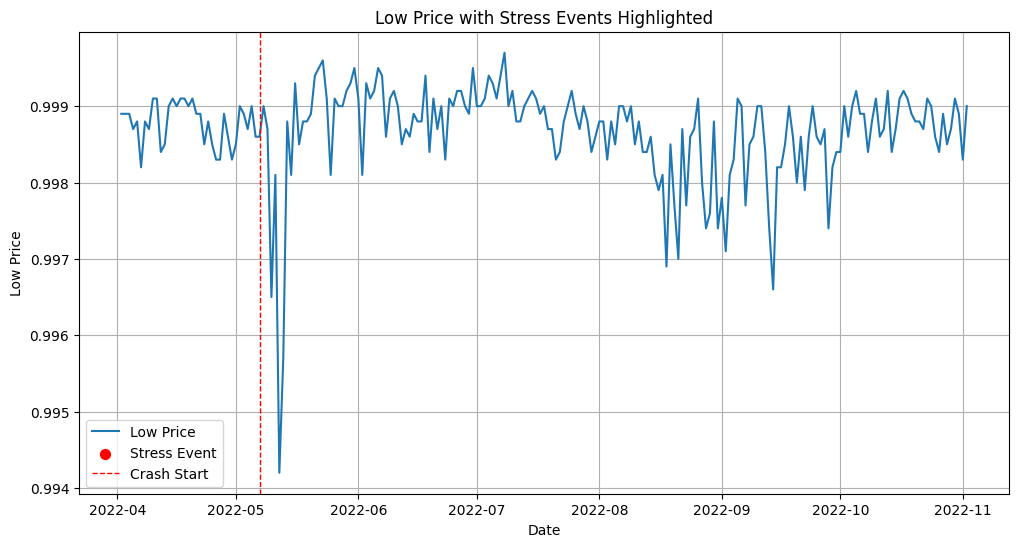

Stress events (sudden drops >20%):
Empty DataFrame
Columns: [Close, Close_daily_return]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, timestamp, Open, High, Low, Close, date, coins, Open_daily_return, Open_stress_flag, High_daily_return, High_stress_flag, Low_daily_return, Low_stress_flag, Close_daily_return, Close_stress_flag]
Index: []


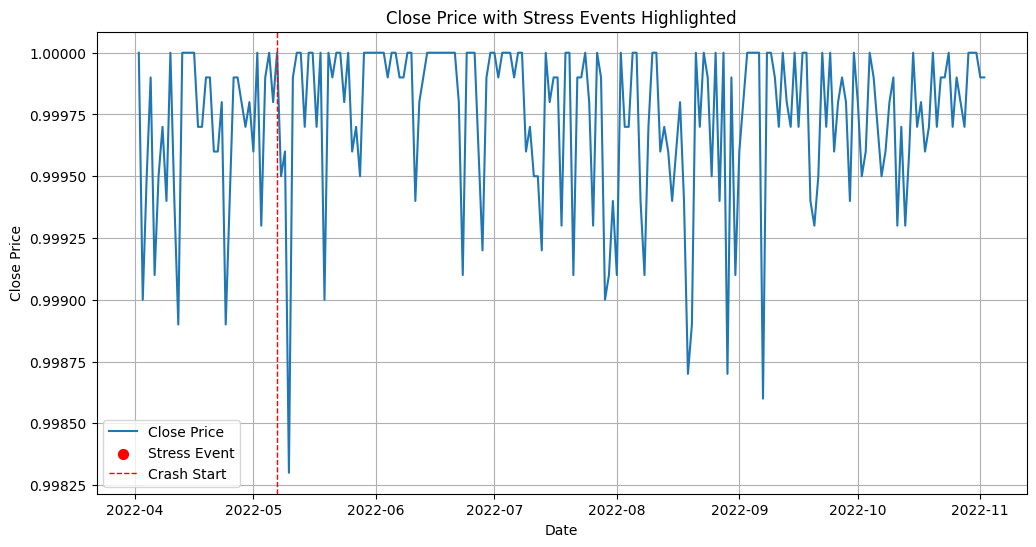

     Unnamed: 0   timestamp    Open  High     Low   Close       date coins
0             0  1648857600  0.9999   1.0  0.9989  1.0000 2022-04-02   dai
1             1  1648944000  1.0000   1.0  0.9989  0.9990 2022-04-03   dai
2             2  1649030400  0.9990   1.0  0.9989  0.9995 2022-04-04   dai
3             3  1649116800  0.9994   1.0  0.9987  0.9999 2022-04-05   dai
4             4  1649203200  0.9999   1.0  0.9988  0.9991 2022-04-06   dai
..          ...         ...     ...   ...     ...     ...        ...   ...
210         210  1667001600  0.9997   1.0  0.9987  1.0000 2022-10-29   dai
211         211  1667088000  1.0000   1.0  0.9991  1.0000 2022-10-30   dai
212         212  1667174400  1.0000   1.0  0.9989  1.0000 2022-10-31   dai
213         213  1667260800  1.0000   1.0  0.9983  0.9999 2022-11-01   dai
214         214  1667347200  0.9999   1.0  0.9990  0.9999 2022-11-02   dai

[215 rows x 8 columns]
Stress events (sudden drops >20%):
Empty DataFrame
Columns: [Open, Open_dail

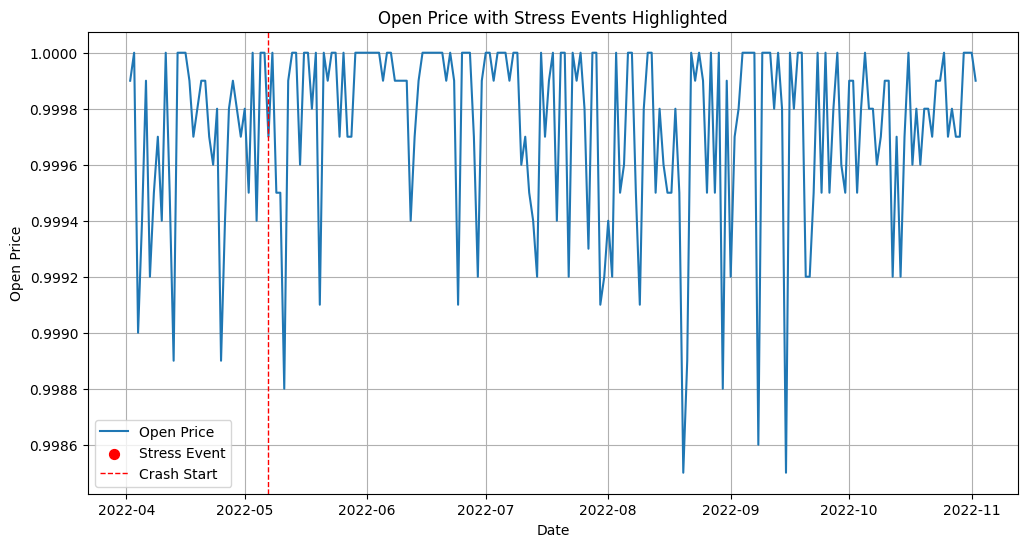

Stress events (sudden drops >20%):
Empty DataFrame
Columns: [High, High_daily_return]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, timestamp, Open, High, Low, Close, date, coins, Open_daily_return, Open_stress_flag, High_daily_return, High_stress_flag]
Index: []


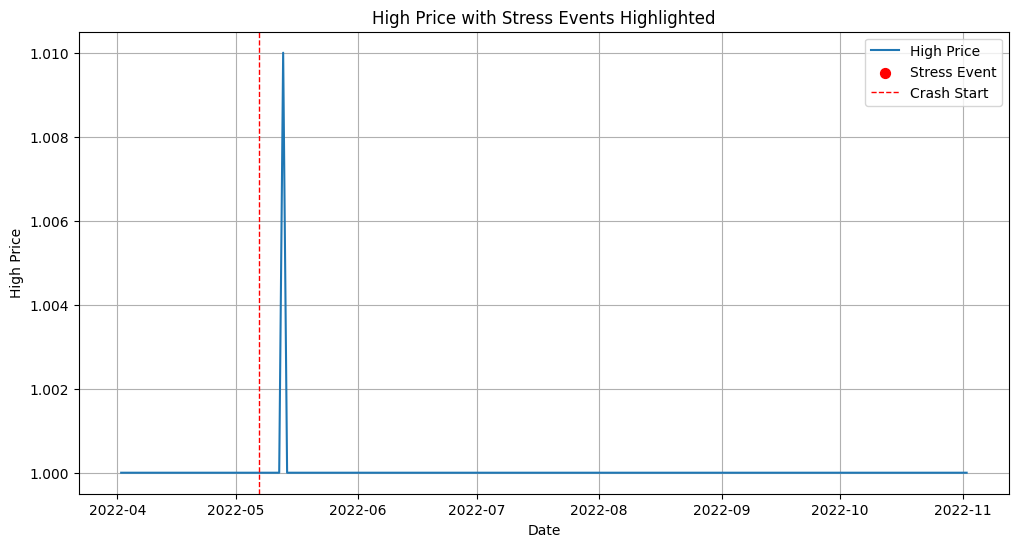

Stress events (sudden drops >20%):
Empty DataFrame
Columns: [Low, Low_daily_return]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, timestamp, Open, High, Low, Close, date, coins, Open_daily_return, Open_stress_flag, High_daily_return, High_stress_flag, Low_daily_return, Low_stress_flag]
Index: []


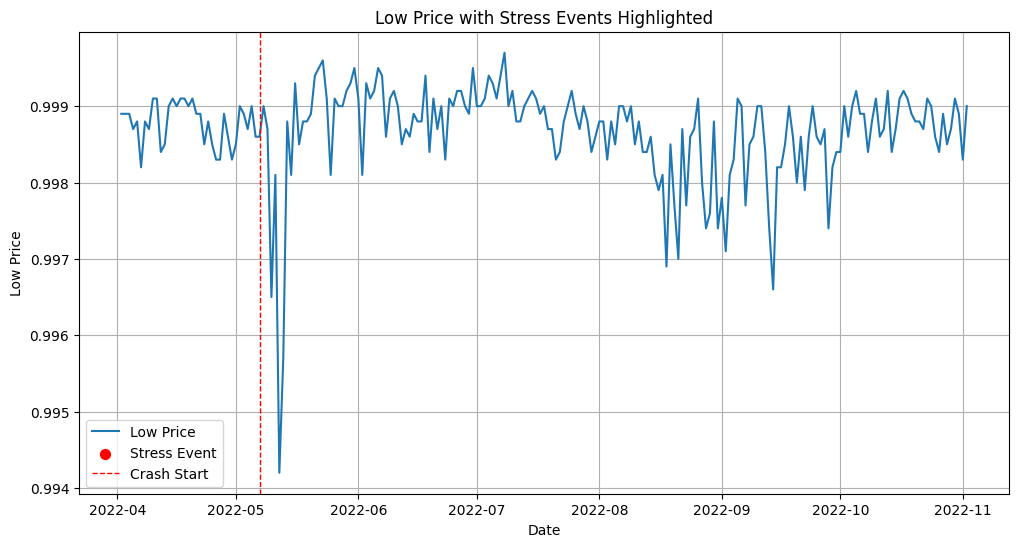

Stress events (sudden drops >20%):
Empty DataFrame
Columns: [Close, Close_daily_return]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, timestamp, Open, High, Low, Close, date, coins, Open_daily_return, Open_stress_flag, High_daily_return, High_stress_flag, Low_daily_return, Low_stress_flag, Close_daily_return, Close_stress_flag]
Index: []


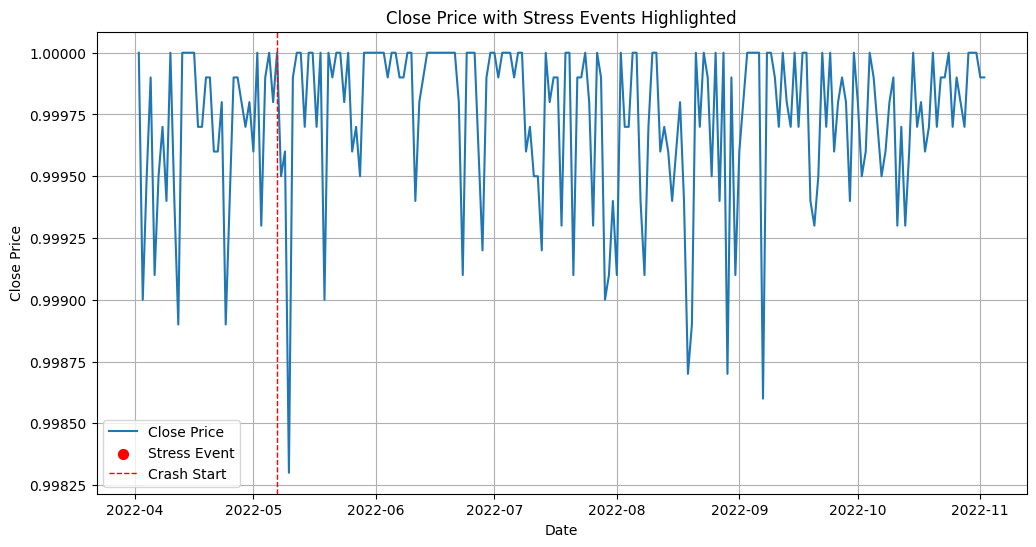

analysing individual candle chart


NameError: name 'col' is not defined

In [74]:
price_data = None
for name, df in erc_20_dfs.items():
    if name.endswith("price_data"):
        print("merging ", name)
        df["coins"] = name.split("_")[0] #because file name is processed_<coin_name>_price_data.csv
        df = df.rename(columns={'open': 'Open', 'low': 'Low', 'close': 'Close', 'high': 'High'})
        stress_event = calc_perc_changes(df, ["Open", "High", "Low", "Close"], "date", False)
        try:
            #calc_moving_avg(df, ["Open", "High", "Low", "Close"], "timestamp")
            calc_perc_changes(df, ["Open", "High", "Low", "Close"], "date",  False)
        except:
            print(f"{name}, do not have Price columns", df.columns)

        if (price_data is None):
            price_data = df
        else:
            price_data = pd.concat([price_data, df])

        print("analysing individual candle chart")
        create_candleLit_graph(stress_event[stress_event[f'{col}_stress_flag']], "stress event", False)
        create_candleLit_graph(df, name.split("_")[0], False)
    if "Unnamed: 0" in df.columns.tolist(): #drop unnamed column
        df.drop("Unnamed: 0", axis=1, inplace=True)

In [75]:
stress_event

,Unnamed: 0,timestamp,Open,High,Low,Close,date,coins,Open_daily_return,Open_stress_flag,High_daily_return,High_stress_flag,Low_daily_return,Low_stress_flag,Close_daily_return,Close_stress_flag
0,0,1648857600,0.9999,1.0,0.9989,1.0000,2022-04-02,dai,NaN,False,NaN,False,NaN,False,NaN,False
1,1,1648944000,1.0000,1.0,0.9989,0.9990,2022-04-03,dai,0.0001,False,0.0,False,0.000000,False,-0.001000,False
2,2,1649030400,0.9990,1.0,0.9989,0.9995,2022-04-04,dai,-0.0010,False,0.0,False,0.000000,False,0.000501,False
3,3,1649116800,0.9994,1.0,0.9987,0.9999,2022-04-05,dai,0.0004,False,0.0,False,-0.000200,False,0.000400,False
4,4,1649203200,0.9999,1.0,0.9988,0.9991,2022-04-06,dai,0.0005,False,0.0,False,0.000100,False,-0.000800,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,210,1667001600,0.9997,1.0,0.9987,1.0000,2022-10-29,dai,0.0000,False,0.0,False,0.000200,False,0.000300,False
211,211,1667088000,1.0000,1.0,0.9991,1.0000,2022-10-30,dai,0.0003,False,0.0,False,0.000401,False,0.000000,False
212,212,1667174400,1.0000,1.0,0.9989,1.0000,2022-10-31,dai,0.0000,False,0.0,False,-0.000200,False,0.000000,False
213,213,1667260800,1.0000,1.0,0.9983,0.9999,2022-11-01,dai,0.0000,False,0.0,False,-0.000601,False,-0.000100,False


In [ ]:
gfc_data = None
for name, df in gfc_dfs.items():
    try :
        #moving window 3
        df['moving_avg_open'] = df['Open'].rolling(window=3).mean()
        df['moving_avg_high'] = df['High'].rolling(window=3).mean()
        df['moving_avg_low'] = df['Low'].rolling(window=3).mean()
        df['moving_avg_close'] = df['Close'].rolling(window=3).mean()
    except:
        print(f"{name} does not have prices value")
    print("merging ", name)
    if (gfc_data is None):
        gfc_data = df
    else:
        gfc_data = pd.concat([gfc_data, df])

    print("analysing individual candle chart")
    create_candleLit_graph(df, name, True)
    if "Unnamed: 0" in df.columns.tolist(): #drop unnamed column
        df.drop("Unnamed: 0", axis=1, inplace=True)

merging  AIG
analysing individual candle chart


merging  C
analysing individual candle chart


merging  JPM
analysing individual candle chart


TEDRATE does not have prices value
merging  TEDRATE
analysing individual candle chart
unable to create candlestick chart
columns in df ['observation_date', 'TEDRATE', 'ticker', 'date']
WGS3MO does not have prices value
merging  WGS3MO
analysing individual candle chart
unable to create candlestick chart
columns in df ['observation_date', 'WGS3MO', 'ticker', 'date']
merging  ^DJI
analysing individual candle chart


merging  ^GSPC
analysing individual candle chart


merging  ^VIX
analysing individual candle chart


In [ ]:
gfc_data

,Price,Close,High,Low,Open,Volume,ticker,date,moving_avg_open,moving_avg_high,moving_avg_low,moving_avg_close,observation_date,TEDRATE,WGS3MO
0,2005-01-04,792.226868,799.999660,790.552699,793.422682,379110.0,AIG,2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-05,805.380432,812.674866,796.651008,797.607644,558800.0,AIG,2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-01-06,806.695984,812.435949,799.999456,801.195269,408765.0,AIG,2005-01-06,797.408532,808.370158,795.734387,801.434428,NaN,NaN,NaN
3,2005-01-07,808.130920,811.718362,804.304302,807.772191,311070.0,AIG,2005-01-07,802.191701,812.276392,800.318255,806.735779,NaN,NaN,NaN
4,2005-01-10,809.565979,811.838055,804.782724,807.413529,253345.0,AIG,2005-01-10,805.460330,811.997455,803.028827,808.130961,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006,2012-12-21,17.840000,19.930000,17.760000,19.850000,0.0,^VIX,2012-12-21,17.720000,18.449999,16.970001,17.623334,NaN,NaN,NaN
2007,2012-12-24,17.840000,18.660000,17.840000,18.459999,0.0,^VIX,2012-12-24,18.523333,18.850000,17.570000,17.783333,NaN,NaN,NaN
2008,2012-12-26,19.480000,19.629999,18.610001,18.709999,0.0,^VIX,2012-12-26,19.006666,19.406666,18.070000,18.386667,NaN,NaN,NaN
2009,2012-12-27,19.469999,20.900000,19.110001,19.389999,0.0,^VIX,2012-12-27,18.853333,19.730000,18.520000,18.930000,NaN,NaN,NaN


In [ ]:
price_data

,timestamp,Open,High,Low,Close,date,coins,Unnamed: 0
0,1648857600,0.999900,1.000000,0.998900,1.000000,2022-04-02,dai,NaN
1,1648944000,1.000000,1.000000,0.998900,0.999000,2022-04-03,dai,NaN
2,1649030400,0.999000,1.000000,0.998900,0.999500,2022-04-04,dai,NaN
3,1649116800,0.999400,1.000000,0.998700,0.999900,2022-04-05,dai,NaN
4,1649203200,0.999900,1.000000,0.998800,0.999100,2022-04-06,dai,NaN
...,...,...,...,...,...,...,...,...
210,1667001600,0.000239,0.000252,0.000235,0.000241,2022-10-29,wluna,210.0
211,1667088000,0.000241,0.000249,0.000229,0.000236,2022-10-30,wluna,211.0
212,1667174400,0.000236,0.000268,0.000230,0.000244,2022-10-31,wluna,212.0
213,1667260800,0.000244,0.000255,0.000233,0.000236,2022-11-01,wluna,213.0


# Analysing data

In [ ]:
gfc_data

,Price,Close,High,Low,Open,Volume,ticker,date,moving_avg_open,moving_avg_high,moving_avg_low,moving_avg_close,observation_date,TEDRATE,WGS3MO
0,2005-01-04,792.226868,799.999660,790.552699,793.422682,379110.0,AIG,2005-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005-01-05,805.380432,812.674866,796.651008,797.607644,558800.0,AIG,2005-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-01-06,806.695984,812.435949,799.999456,801.195269,408765.0,AIG,2005-01-06,797.408532,808.370158,795.734387,801.434428,NaN,NaN,NaN
3,2005-01-07,808.130920,811.718362,804.304302,807.772191,311070.0,AIG,2005-01-07,802.191701,812.276392,800.318255,806.735779,NaN,NaN,NaN
4,2005-01-10,809.565979,811.838055,804.782724,807.413529,253345.0,AIG,2005-01-10,805.460330,811.997455,803.028827,808.130961,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006,2012-12-21,17.840000,19.930000,17.760000,19.850000,0.0,^VIX,2012-12-21,17.720000,18.449999,16.970001,17.623334,NaN,NaN,NaN
2007,2012-12-24,17.840000,18.660000,17.840000,18.459999,0.0,^VIX,2012-12-24,18.523333,18.850000,17.570000,17.783333,NaN,NaN,NaN
2008,2012-12-26,19.480000,19.629999,18.610001,18.709999,0.0,^VIX,2012-12-26,19.006666,19.406666,18.070000,18.386667,NaN,NaN,NaN
2009,2012-12-27,19.469999,20.900000,19.110001,19.389999,0.0,^VIX,2012-12-27,18.853333,19.730000,18.520000,18.930000,NaN,NaN,NaN


In [ ]:
price_data

,timestamp,Open,High,Low,Close,date,coins,moving_avg_open,moving_avg_high,moving_avg_low,moving_avg_close,Unnamed: 0
0,1648857600,0.999900,1.000000,0.998900,1.000000,2022-04-02,dai,NaN,NaN,NaN,NaN,NaN
1,1648944000,1.000000,1.000000,0.998900,0.999000,2022-04-03,dai,NaN,NaN,NaN,NaN,NaN
2,1649030400,0.999000,1.000000,0.998900,0.999500,2022-04-04,dai,0.999633,1.000000,0.998900,0.999500,NaN
3,1649116800,0.999400,1.000000,0.998700,0.999900,2022-04-05,dai,0.999467,1.000000,0.998833,0.999467,NaN
4,1649203200,0.999900,1.000000,0.998800,0.999100,2022-04-06,dai,0.999433,1.000000,0.998800,0.999500,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
210,1667001600,0.000239,0.000252,0.000235,0.000241,2022-10-29,wluna,0.000239,0.000252,0.000232,0.000239,210.0
211,1667088000,0.000241,0.000249,0.000229,0.000236,2022-10-30,wluna,0.000239,0.000251,0.000233,0.000239,211.0
212,1667174400,0.000236,0.000268,0.000230,0.000244,2022-10-31,wluna,0.000239,0.000256,0.000231,0.000240,212.0
213,1667260800,0.000244,0.000255,0.000233,0.000236,2022-11-01,wluna,0.000240,0.000257,0.000231,0.000238,213.0


## Analysing coin prices for ERC20

In [ ]:
create_line_graph(price_data[price_data['coins'] != "wluna"], 'date', 'Open', 'coins')
create_line_graph(price_data[price_data['coins'] != "wluna"], 'date', 'Close', 'coins')
create_line_graph(price_data[price_data['coins'] != "wluna"], 'date', 'High', 'coins')
create_line_graph(price_data[price_data['coins'] != "wluna"], 'date', 'Low', 'coins')


In [ ]:
create_line_graph(price_data[~price_data['coins'].isin(["wluna", "ustc"])], 'date', 'Opytpen', 'coins', True)
create_line_graph(price_data[~price_data['coins'].isin(["wluna", "ustc"])], 'date', 'Close', 'coins', True)
create_line_graph(price_data[~price_data['coins'].isin(["wluna", "ustc"])], 'date', 'High', 'coins', True)
create_line_graph(price_data[~price_data['coins'].isin(["wluna", "ustc"])], 'date', 'Low', 'coins', True)


NameError: name 'create_line_graph' is not defined